In [92]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split

from pathlib import Path



In [93]:
DATA = Path('..') / 'data'
housing = pd.read_csv(DATA / "housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [94]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [95]:
housing.isna().sum().sort_values(ascending=False)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

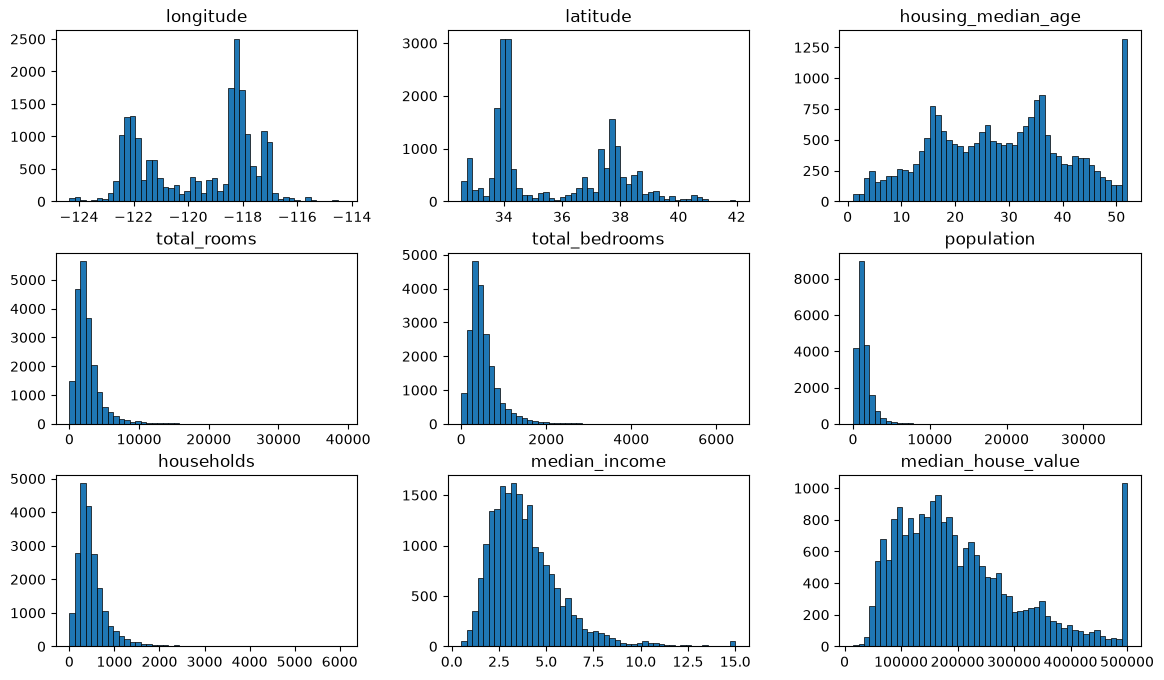

In [96]:
housing.hist(figsize=(14,8), bins=50, edgecolor='black', linewidth=0.5, grid=False)
plt.show()

Queremos separar la data de entramiento de la de test. En el libro separa primero de esta forma, no directamente en features y target (X_train, X_test, y_train, y_test)

Para estratificar necesitamos una columna categorica o discreta, si tenemos una variable continua tenemos que usar cut para separar los valores por bines.

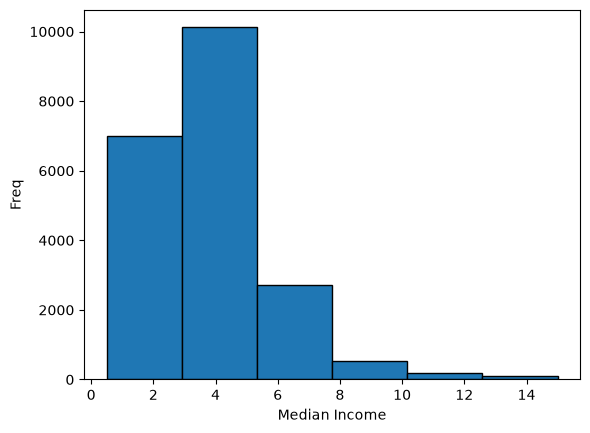

In [97]:
housing['median_income'].hist(bins=6, edgecolor='black', grid=False)

plt.xlabel('Median Income')
plt.ylabel('Freq')

plt.show()

In [98]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3 , 4, 5])

In [99]:
housing.income_cat.value_counts().sort_values(ascending=False)

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

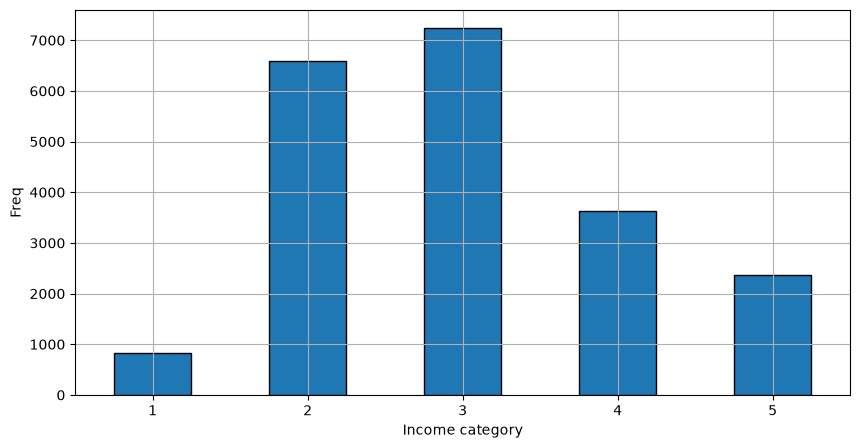

In [100]:
fig, ax = plt.subplots(figsize=(10,5))
housing['income_cat'].value_counts().sort_index().plot(kind='bar', edgecolor='black', rot=0, grid=True)
ax.set_xlabel('Income category')
ax.set_ylabel('Freq')

plt.show()

Defino el set de entrenamiento y test

In [101]:
data_train, data_test = train_test_split(housing, test_size=0.2, stratify=housing['income_cat'], random_state=42)

Las proporciones estan bien

In [102]:
data_test['income_cat'].value_counts()/data_test.shape[0]*100

income_cat
3    35.053295
2    31.879845
4    17.635659
5    11.434109
1     3.997093
Name: count, dtype: float64

In [103]:
housing['income_cat'].value_counts()/len(housing)*100

income_cat
3    35.058140
2    31.884690
4    17.630814
5    11.443798
1     3.982558
Name: count, dtype: float64

No vamos a volver a usar esta categoria entonces la borro

In [104]:
for set_ in (data_train, data_test):
    set_.drop(columns='income_cat', inplace=True)
    print('-'*50)

--------------------------------------------------
--------------------------------------------------


In [105]:
housing = data_train.copy()

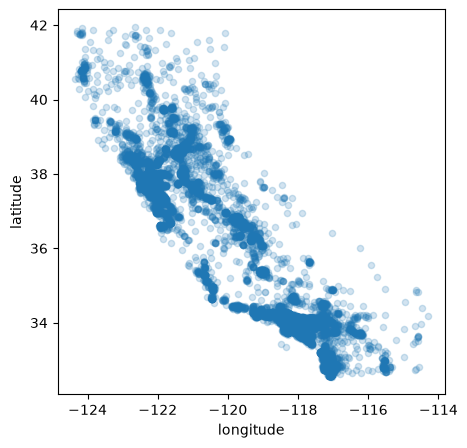

In [106]:
fig, ax = plt.subplots(figsize=(5,5))
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.2, ax=ax)

plt.show()


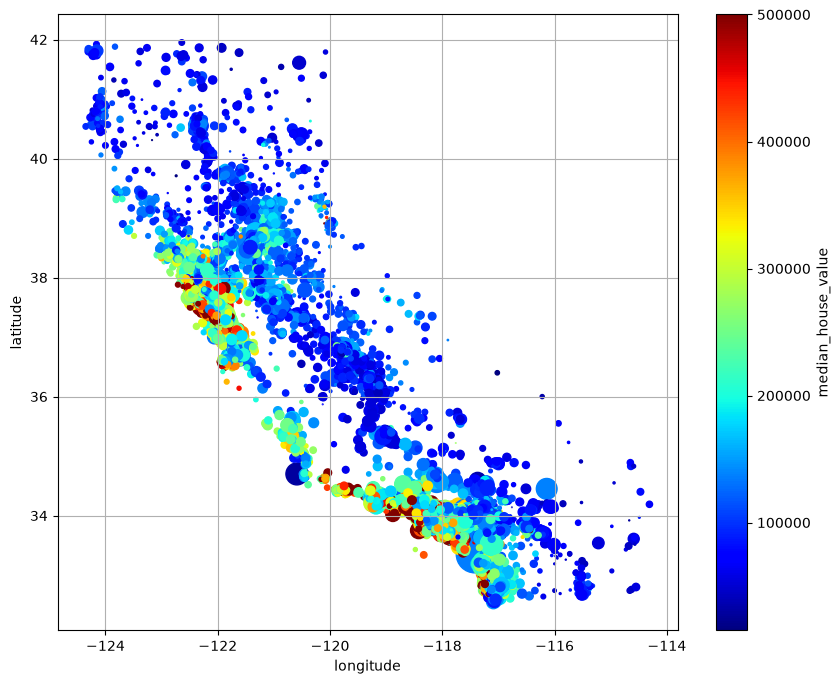

In [107]:
fig, ax = plt.subplots(figsize=(10,8))
housing.plot(kind='scatter', x='longitude', y='latitude', s=housing['population']/50,c='median_house_value', cmap='jet', colorbar=True, grid=True, ax=ax)

plt.show()

Seguimos con mas exploracion de datos:
* Queremos ver que datos tienen buena correlacion con el target. (Pearson, Spearman, ...)
* Para ver correlacion tambien podes ver graficos de scatters entre el target y otros features
* Por otro lado quisieramos ver si hay datos raros (outliers) o las features
* NO SE QUE MAS

In [108]:
corr_matrix = housing.select_dtypes(include='number').corr()
corr_matrix.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924478,-0.105823,0.048909,0.076686,0.108071,0.063146,-0.019615,-0.047466
latitude,-0.924478,1.000000,0.005737,-0.039245,-0.072550,-0.115290,-0.077765,-0.075146,-0.142673
housing_median_age,-0.105823,0.005737,1.000000,-0.364535,-0.325101,-0.298737,-0.306473,-0.111315,0.114146
total_rooms,0.048909,-0.039245,-0.364535,1.000000,0.929391,0.855103,0.918396,0.200133,0.135140
total_bedrooms,0.076686,-0.072550,-0.325101,0.929391,1.000000,0.876324,0.980167,-0.009643,0.047781


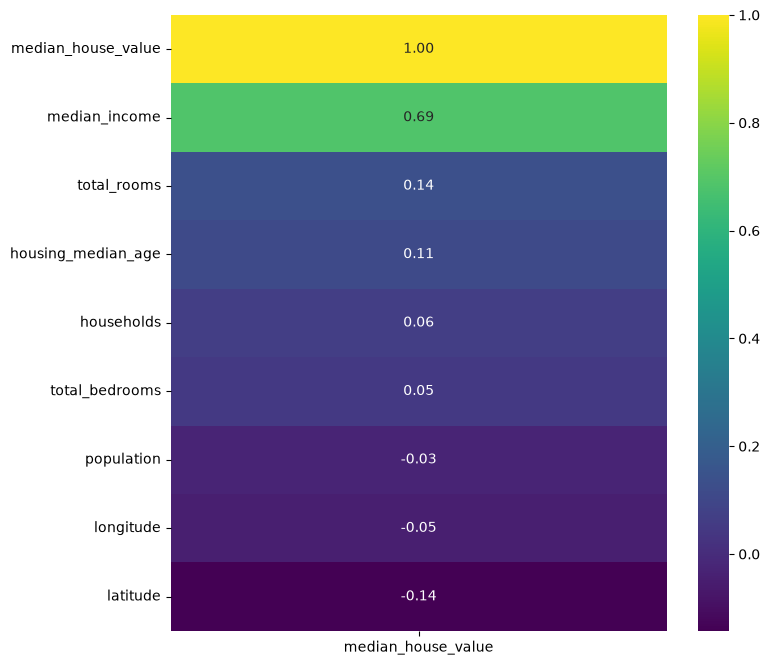

In [109]:
fig, ax = plt.subplots(figsize=(8,8))
#sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=sns.color_palette('Spectral',as_cmap=True), ax=ax)
sns.heatmap(corr_matrix[['median_house_value']].sort_values(by='median_house_value', ascending=False), annot=True, fmt='.2f', cmap='viridis', ax=ax)

plt.show()

In [110]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

Tomamos los elementos con mayor correlacion para ver los graficos de scatter

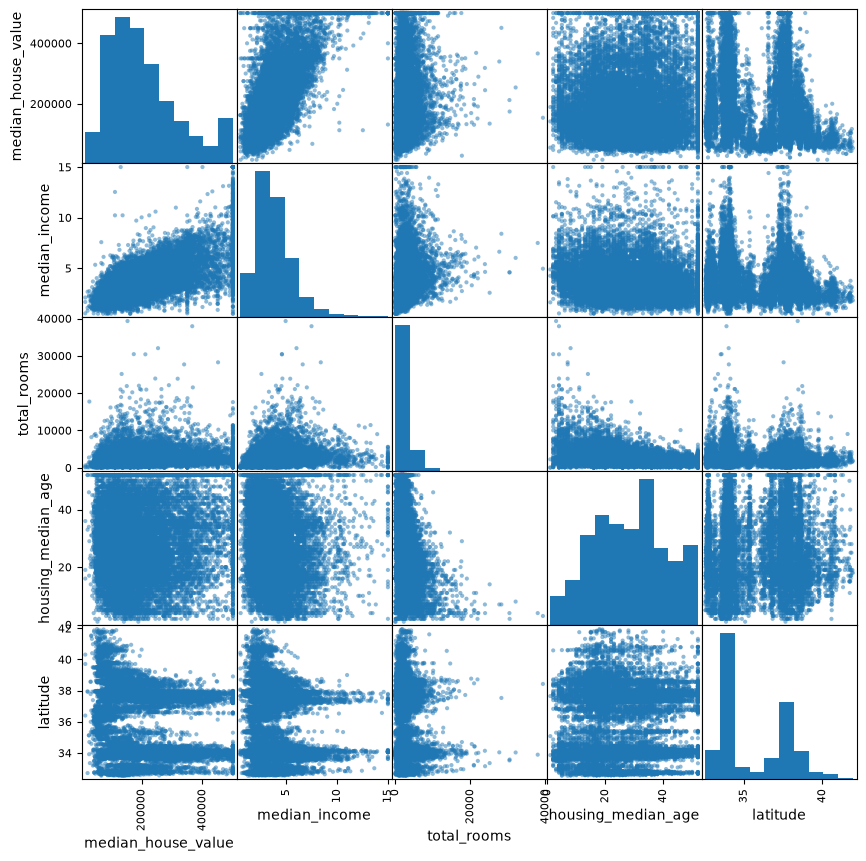

In [111]:
features = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age', 'latitude']

scatter_matrix(housing[features], figsize=(10,10))

plt.show()

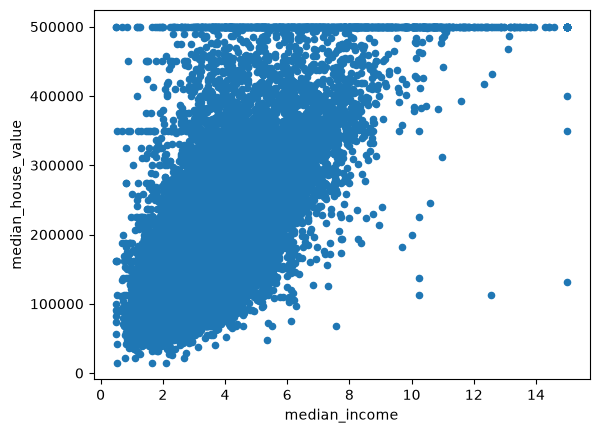

In [112]:
fig, ax = plt.subplots()
housing.plot(kind='scatter', y='median_house_value', x='median_income', ax=ax)

plt.show()

In [113]:
housing[housing['median_house_value'] == 500000].sort_values(by='median_income')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9850,-121.89,36.60,19.0,656.0,200.0,248.0,173.0,1.2656,500000.0,<1H OCEAN
15311,-117.38,33.19,26.0,4123.0,1145.0,1703.0,895.0,1.9891,500000.0,NEAR OCEAN
5301,-118.45,34.06,20.0,3367.0,1264.0,2667.0,1131.0,2.2444,500000.0,<1H OCEAN
4823,-118.31,34.05,26.0,1809.0,640.0,2543.0,640.0,2.3536,500000.0,<1H OCEAN
17276,-119.69,34.41,44.0,1208.0,357.0,603.0,297.0,2.6103,500000.0,<1H OCEAN
15670,-122.44,37.80,52.0,1006.0,291.0,445.0,257.0,2.7717,500000.0,NEAR BAY
15754,-122.45,37.77,52.0,2191.0,627.0,1100.0,585.0,3.0409,500000.0,NEAR BAY
15679,-122.43,37.80,52.0,1006.0,251.0,349.0,233.0,3.2235,500000.0,NEAR BAY
4719,-118.38,34.06,25.0,2558.0,661.0,1183.0,636.0,3.5556,500000.0,<1H OCEAN
15979,-122.45,37.76,31.0,5283.0,1330.0,2659.0,1269.0,3.5744,500000.0,NEAR BAY


In [114]:
housing[['median_income']].sort_values('median_income')

,median_income
4861,0.4999
19800,0.4999
7125,0.4999
6688,0.4999
3258,0.4999
...,...
18504,15.0001
17170,15.0001
8878,15.0001
5242,15.0001


Podemos crear features nuevas y ver la correlacion nueva. (feature engineering
)

In [115]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN


In [116]:
housing['rooms_per_house'] = housing['total_bedrooms']/housing['households']
housing['persons_per_room'] = housing['population']/housing['total_rooms']
housing['persons_per_house'] = housing['population']/housing['households']
housing['ratio_bedroom_rooms'] = housing['total_bedrooms']/housing['total_rooms']

In [117]:
corr_matrix = housing.select_dtypes(include='number').corr()
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value     1.000000
median_income          0.687151
total_rooms            0.135140
housing_median_age     0.114146
households             0.064590
total_bedrooms         0.047781
persons_per_house     -0.021991
population            -0.026882
persons_per_room      -0.031082
rooms_per_house       -0.043349
longitude             -0.047466
latitude              -0.142673
ratio_bedroom_rooms   -0.259952
Name: median_house_value, dtype: float64

Creamos X_train y y_train

In [118]:
X_train = housing.drop(columns='median_house_value')
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_house,persons_per_room,persons_per_house,ratio_bedroom_rooms
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,1.128895,0.577588,3.168555,0.205784
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,1.113281,0.378759,2.623698,0.160714
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,1.033333,0.412237,2.223333,0.191595
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,1.074534,0.478423,1.859213,0.276505
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,1.113793,0.519514,3.167241,0.182692
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,<1H OCEAN,1.229770,0.303976,2.023976,0.184696
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,INLAND,1.002821,0.603594,3.363188,0.179977
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,<1H OCEAN,0.965116,0.647808,2.662791,0.234795
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,<1H OCEAN,1.157685,0.382884,2.411178,0.183835


In [119]:
y_train = housing['median_house_value'].copy()
y_train.head()

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

# Tratamiento de los NaN en el DF

Tenemos que limpiar los valores NaN. Podemos borrar las filas, borras las columnas o imputar

In [120]:
housing.isna().sum().sort_values(ascending=False)

total_bedrooms         158
ratio_bedroom_rooms    158
rooms_per_house        158
housing_median_age       0
latitude                 0
longitude                0
population               0
total_rooms              0
households               0
median_income            0
ocean_proximity          0
median_house_value       0
persons_per_room         0
persons_per_house        0
dtype: int64

In [121]:
null_rows_idx = housing.isnull().any(axis=1)
null_rows_idx

12655    False
15502    False
2908     False
14053    False
20496    False
         ...  
15174    False
12661    False
19263    False
19140    False
19773    False
Length: 16512, dtype: bool

In [122]:
housing[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_house,persons_per_room,persons_per_house,ratio_bedroom_rooms
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,85000.0,NEAR BAY,NaN,0.279946,1.317891,NaN
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,177000.0,<1H OCEAN,NaN,0.870141,3.947896,NaN
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,146500.0,<1H OCEAN,NaN,0.412451,2.403023,NaN
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,214800.0,<1H OCEAN,NaN,0.638379,2.840136,NaN
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,500001.0,NEAR OCEAN,NaN,0.348979,2.385417,NaN


Podemos limpiar tambien los outliers tanto de X_train como de y_train

In [123]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
mask = isolation_forest.fit_predict(X_train.select_dtypes(include='number')) == 1

In [124]:
X_train = X_train[mask]
y_train = y_train[mask]

---
# Arranco de cero la parte de hacer los pipelines

In [131]:
housing = data_train.drop(columns='median_house_value')
housing_labels = data_train['median_house_value'].copy()

In [132]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN


In [141]:
num_features = housing.select_dtypes('number').columns
cat_features = housing.select_dtypes('str').columns

In [150]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline

num_pipeline = Pipeline([
    ('imputar', SimpleImputer(strategy='median')),
    ('standarizar', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputar', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [151]:
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

In [145]:
housing_prepared = preprocessing.fit_transform(housing)

In [146]:
housing_prepared_df = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index
)

housing_prepared_df.head()

,num__longitude,num__latitude,num__housing_median_age,num__total_rooms,num__total_bedrooms,num__population,num__households,num__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN
12655,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.0,1.0,0.0,0.0,0.0
15502,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.0,0.0,0.0,0.0,1.0
2908,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,0.0,1.0,0.0,0.0,0.0
14053,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,0.0,0.0,0.0,0.0,1.0
20496,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,1.0,0.0,0.0,0.0,0.0


Ahora queremos hacer todo lo que hicimos anteriormente, imputar, estandarizar, crear nuevas features, usar el OneHotEncoder, etc, utilizando solo pipelines. Abajo esta todo lo que tiene que hacer el pipeline

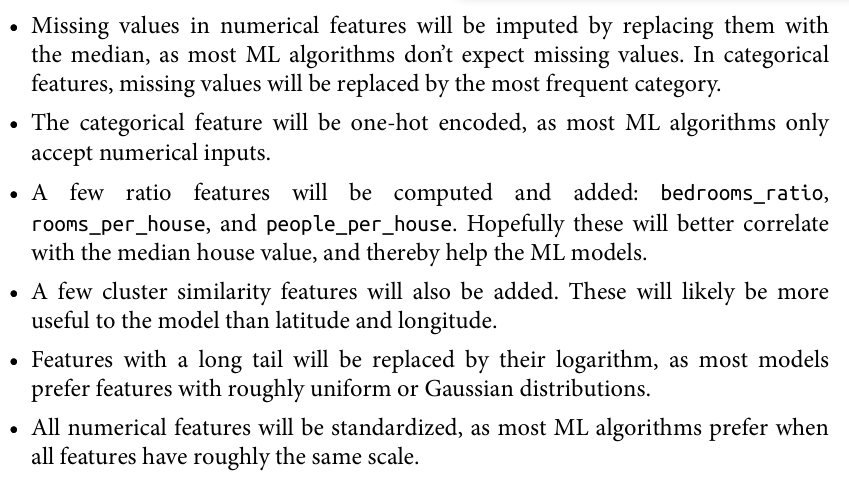

Primero vamos a armar el transformador cluster similarity

In [171]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.compose import make_column_selector

from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator,TransformerMixin):
    def __init__(self, n_cluster=10, gamma=1.0, random_state=None):
        self.n_cluster = n_cluster
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_cluster, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f'Cluster {i} similarity' for i in range(self.n_cluster)]


In [172]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, feature_names_out='one-to-one'),
    StandardScaler()
)

cluster_simil = ClusterSimilarity(n_cluster=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
    ('people_per_house', ratio_pipeline(), ['population', 'households']),
    ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ('geo', cluster_simil, ['latitude', 'longitude']),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline)

In [173]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape


(16512, 24)

In [174]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

---
# Cosas extras
Queria ver como podia hacer la funcion max min scaler para cualquier rango que quisiera.

In [125]:
serie = housing['total_rooms']

def scaler(s, y_min=-25, y_max=10):
    f_max = s.max()
    f_min = s.min()

    g = s - f_min
    h = g*(y_max - y_min)/(f_max - f_min)
    l = h + y_min

    return l.to_frame()


df_trans = scaler(serie)
print(df_trans.min(), df_trans.max())


total_rooms   -25.0
dtype: float64 total_rooms    10.0
dtype: float64


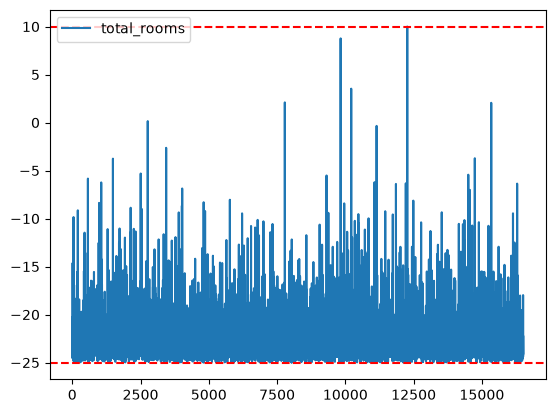

In [126]:
fig, ax = plt.subplots()
df_trans.reset_index().drop(columns='index').plot(ax=ax)

ax.axhline(df_trans.max().item(), color='red', linestyle='--', label='max')
ax.axhline(df_trans.min().item(), color='red', linestyle='--', label='min')

plt.show()

In [127]:
df_trans

,total_rooms
12655,-21.557333
15502,-20.269115
2908,-23.564888
14053,-23.334308
20496,-21.857354
...,...
15174,-19.071705
12661,-17.971333
19263,-24.375922
19140,-22.196546
